# 🏠 House Price Prediction and Analysis Using Machine Learning
**IBM SkillsBuild – Data Analytics with AI Academic Internship Project**

---
**Student Name:** Haveesh Chowdary Kante  
**Institution:** Amrita Vishwa Vidyapeetham, Coimbatore  
**Dataset:** India House Price Prediction (Kaggle)

## 1. Introduction

This project aims to predict house prices in India using machine learning regression models. Real estate pricing is influenced by many factors including location, property size, amenities, and the price per square foot. By analysing a large housing dataset, we build models that estimate the price of a house given its features.

This notebook follows a complete data analytics pipeline:
- Loading and understanding the dataset
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering and preprocessing
- Model building and evaluation
- Feature importance and sample predictions
- Conclusions and future scope

## 2. Problem Statement

House prices in India vary widely based on location, property size, amenities, and market factors. The challenge is to:
> **Predict the price of a house (in Lakhs ₹) based on its physical characteristics, location, pricing rate, and amenity features.**

This prediction can help buyers, sellers, and real estate agents make better and more informed decisions.

## 3. Objectives

1. Load and explore the India House Price dataset.
2. Clean the data and handle any quality issues.
3. Perform meaningful Exploratory Data Analysis (EDA) to understand price-influencing factors.
4. Build and compare multiple machine learning regression models.
5. Evaluate models using standard metrics (MAE, MSE, RMSE, R²).
6. Identify the best-performing model and analyse feature importance.
7. Draw conclusions and suggest future improvements.

## 4. Dataset Description

**Source:** India House Price Prediction – Kaggle  
**Link:** https://www.kaggle.com/datasets/ankushpanday1/india-house-price-prediction

The dataset contains **250,000 records** of residential properties across 20 Indian states and 42 cities.

| Column | Type | Description |
|---|---|---|
| ID | int | Unique property identifier |
| State | str | State where property is located |
| City | str | City of the property |
| Locality | str | Locality within the city |
| Property_Type | str | Apartment / Independent House / Villa |
| BHK | int | Number of bedrooms (1–5) |
| Size_in_SqFt | int | Property area in square feet |
| **Price_in_Lakhs** | float | **Target: Price in Indian Lakhs (₹)** |
| Price_per_SqFt | float | Price per square foot (₹) — key pricing attribute |
| Year_Built | int | Year the property was constructed |
| Furnished_Status | str | Furnished / Semi-furnished / Unfurnished |
| Floor_No | int | Floor number of the property |
| Total_Floors | int | Total floors in the building |
| Age_of_Property | int | Age of property in years |
| Nearby_Schools | int | Number of nearby schools |
| Nearby_Hospitals | int | Number of nearby hospitals |
| Public_Transport_Accessibility | str | High / Medium / Low |
| Parking_Space | str | Yes / No |
| Security | str | Yes / No |
| Amenities | str | List of available amenities |
| Facing | str | Direction the property faces |
| Owner_Type | str | Owner / Builder / Broker |
| Availability_Status | str | Ready_to_Move / Under_Construction |

## 5. Import Libraries

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn – preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Scikit-learn – models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Scikit-learn – metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
RANDOM_STATE = 42

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully.')

All libraries imported successfully.


## 6. Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('india_house_prices.csv')

print('Dataset loaded successfully.')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded successfully.
Shape: 250000 rows x 23 columns


## 7. Data Understanding

In [3]:
# First five rows
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [4]:
# Column names and data types
print('Column Names and Data Types:')
print(df.dtypes)

Column Names and Data Types:
ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
dtype

In [5]:
# Basic descriptive statistics for numerical columns
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [6]:
# Descriptive statistics for categorical columns
df.describe(include='object')

,State,City,Locality,Property_Type,Furnished_Status,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
count,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000
unique,20,42,500,3,3,3,2,2,325,4,3,2
top,Odisha,Coimbatore,Locality_296,Villa,Unfurnished,High,No,Yes,Pool,West,Broker,Under_Construction
freq,12681,6461,567,83744,83408,83705,125456,125233,10218,62757,83479,125035


## 8. Data Cleaning

In [7]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing values per column:
No missing values found.


In [8]:
# Check for duplicate records
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print('Duplicates removed.')
else:
    print('No duplicates found. Dataset is clean.')

Number of duplicate rows: 0
No duplicates found. Dataset is clean.


In [9]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Remove ID and target from general lists for analysis purposes
numerical_cols = [c for c in numerical_cols if c not in ['ID', 'Price_in_Lakhs']]

print('Numerical columns:', numerical_cols)
print()
print('Categorical columns:', categorical_cols)

Numerical columns: ['BHK', 'Size_in_SqFt', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']

Categorical columns: ['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


In [10]:
# Inspect unique values for key categorical columns
for col in ['Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility',
            'Parking_Space', 'Security', 'Facing', 'Owner_Type', 'Availability_Status']:
    print(f'{col} ({df[col].nunique()} unique): {sorted(df[col].dropna().unique().tolist())}')

Property_Type (3 unique): ['Apartment', 'Independent House', 'Villa']
Furnished_Status (3 unique): ['Furnished', 'Semi-furnished', 'Unfurnished']
Public_Transport_Accessibility (3 unique): ['High', 'Low', 'Medium']
Parking_Space (2 unique): ['No', 'Yes']
Security (2 unique): ['No', 'Yes']
Facing (4 unique): ['East', 'North', 'South', 'West']


Owner_Type (3 unique): ['Broker', 'Builder', 'Owner']


Availability_Status (2 unique): ['Ready_to_Move', 'Under_Construction']


In [11]:
# Feature Engineering: Convert Amenities text list into a numerical count.
# The Amenities column contains comma-separated strings (e.g. 'Gym, Pool, Garden').
# We count the amenities to create a useful numerical feature.
df['Amenities_Count'] = df['Amenities'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

print('Amenities_Count sample:')
print(df[['Amenities', 'Amenities_Count']].head())

Amenities_Count sample:
                                  Amenities  Amenities_Count
0  Playground, Gym, Garden, Pool, Clubhouse                5
1  Playground, Clubhouse, Pool, Gym, Garden                5
2          Clubhouse, Pool, Playground, Gym                4
3  Playground, Clubhouse, Gym, Pool, Garden                5
4  Playground, Garden, Gym, Pool, Clubhouse                5


In [12]:
# Drop columns that cannot contribute to modelling:
# - ID: unique identifier with no predictive value.
# - Locality: 500+ unique text values — too high-cardinality for simple encoding.
# - Amenities: replaced by numerical Amenities_Count feature.
# - City: 42 cities already captured at a broader level by State.
drop_cols = ['ID', 'Locality', 'Amenities', 'City']
df.drop(columns=drop_cols, inplace=True)

print('Columns after cleaning:')
print(df.columns.tolist())
print('Shape:', df.shape)

Columns after cleaning:
['State', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Facing', 'Owner_Type', 'Availability_Status', 'Amenities_Count']
Shape: (250000, 20)


In [13]:
# Verify there are no unrealistic values in key columns
print('BHK range             :', df['BHK'].min(), '-', df['BHK'].max())
print('Size_in_SqFt range    :', df['Size_in_SqFt'].min(), '-', df['Size_in_SqFt'].max())
print('Price_in_Lakhs range  :', df['Price_in_Lakhs'].min(), '-', df['Price_in_Lakhs'].max())
print('Price_per_SqFt range  :', df['Price_per_SqFt'].min(), '-', df['Price_per_SqFt'].max())
print('Year_Built range      :', df['Year_Built'].min(), '-', df['Year_Built'].max())
print('Age_of_Property range :', df['Age_of_Property'].min(), '-', df['Age_of_Property'].max())

BHK range             : 1 - 5
Size_in_SqFt range    : 500 - 5000
Price_in_Lakhs range  : 10.0 - 500.0
Price_per_SqFt range  : 0.0 - 0.99
Year_Built range      : 1990 - 2023
Age_of_Property range : 2 - 35


In [14]:
# Final cleaned dataset summary
print(f'Final dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print('Data cleaning complete. No rows were removed.')

Final dataset: 250000 rows x 20 columns
Data cleaning complete. No rows were removed.


## 9. Exploratory Data Analysis (EDA)

### 9.1 Distribution of House Prices (Target Variable)

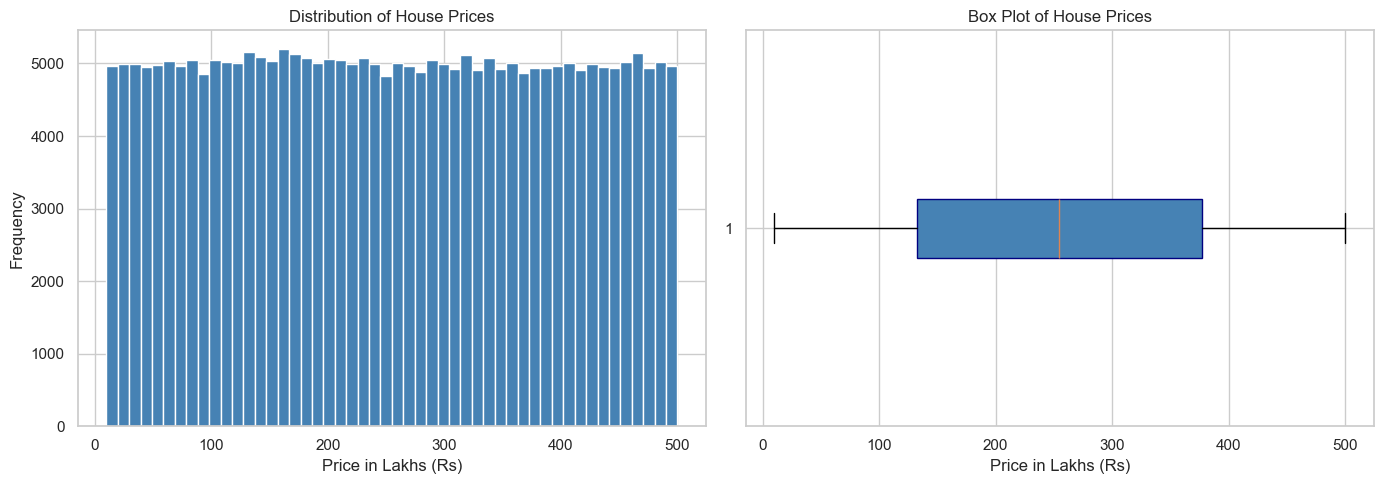

Mean price   : Rs 254.59 Lakhs
Median price : Rs 253.87 Lakhs
Std deviation: Rs 141.35 Lakhs


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price_in_Lakhs'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of House Prices')
axes[0].set_xlabel('Price in Lakhs (Rs)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Price_in_Lakhs'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Box Plot of House Prices')
axes[1].set_xlabel('Price in Lakhs (Rs)')

plt.tight_layout()
plt.show()

print(f'Mean price   : Rs {df["Price_in_Lakhs"].mean():.2f} Lakhs')
print(f'Median price : Rs {df["Price_in_Lakhs"].median():.2f} Lakhs')
print(f'Std deviation: Rs {df["Price_in_Lakhs"].std():.2f} Lakhs')

**Insight:** The price distribution is approximately uniform between Rs 10 and Rs 500 Lakhs, indicating this is a broadly synthetic dataset covering the full market range. Mean and median are very close (~Rs 254 Lakhs).

### 9.2 Distribution of Price Per Square Foot

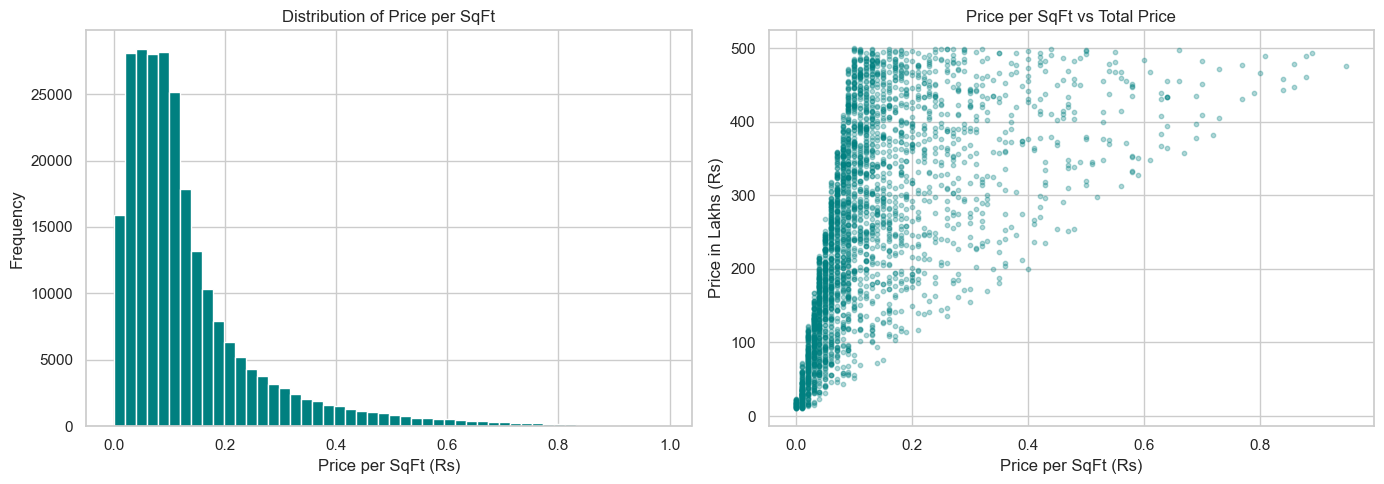

Correlation between Price_per_SqFt and Price_in_Lakhs: 0.5556


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price_per_SqFt'], bins=50, color='teal', edgecolor='white')
axes[0].set_title('Distribution of Price per SqFt')
axes[0].set_xlabel('Price per SqFt (Rs)')
axes[0].set_ylabel('Frequency')

sample = df.sample(3000, random_state=RANDOM_STATE)
axes[1].scatter(sample['Price_per_SqFt'], sample['Price_in_Lakhs'],
                alpha=0.3, color='teal', s=10)
axes[1].set_title('Price per SqFt vs Total Price')
axes[1].set_xlabel('Price per SqFt (Rs)')
axes[1].set_ylabel('Price in Lakhs (Rs)')

plt.tight_layout()
plt.show()

corr_val = df['Price_per_SqFt'].corr(df['Price_in_Lakhs'])
print(f'Correlation between Price_per_SqFt and Price_in_Lakhs: {corr_val:.4f}')

**Insight:** Price_per_SqFt has a moderate positive correlation (~0.56) with Price_in_Lakhs. It is the primary pricing signal in this dataset and will be included as a feature.

### 9.3 Numerical Feature Distributions

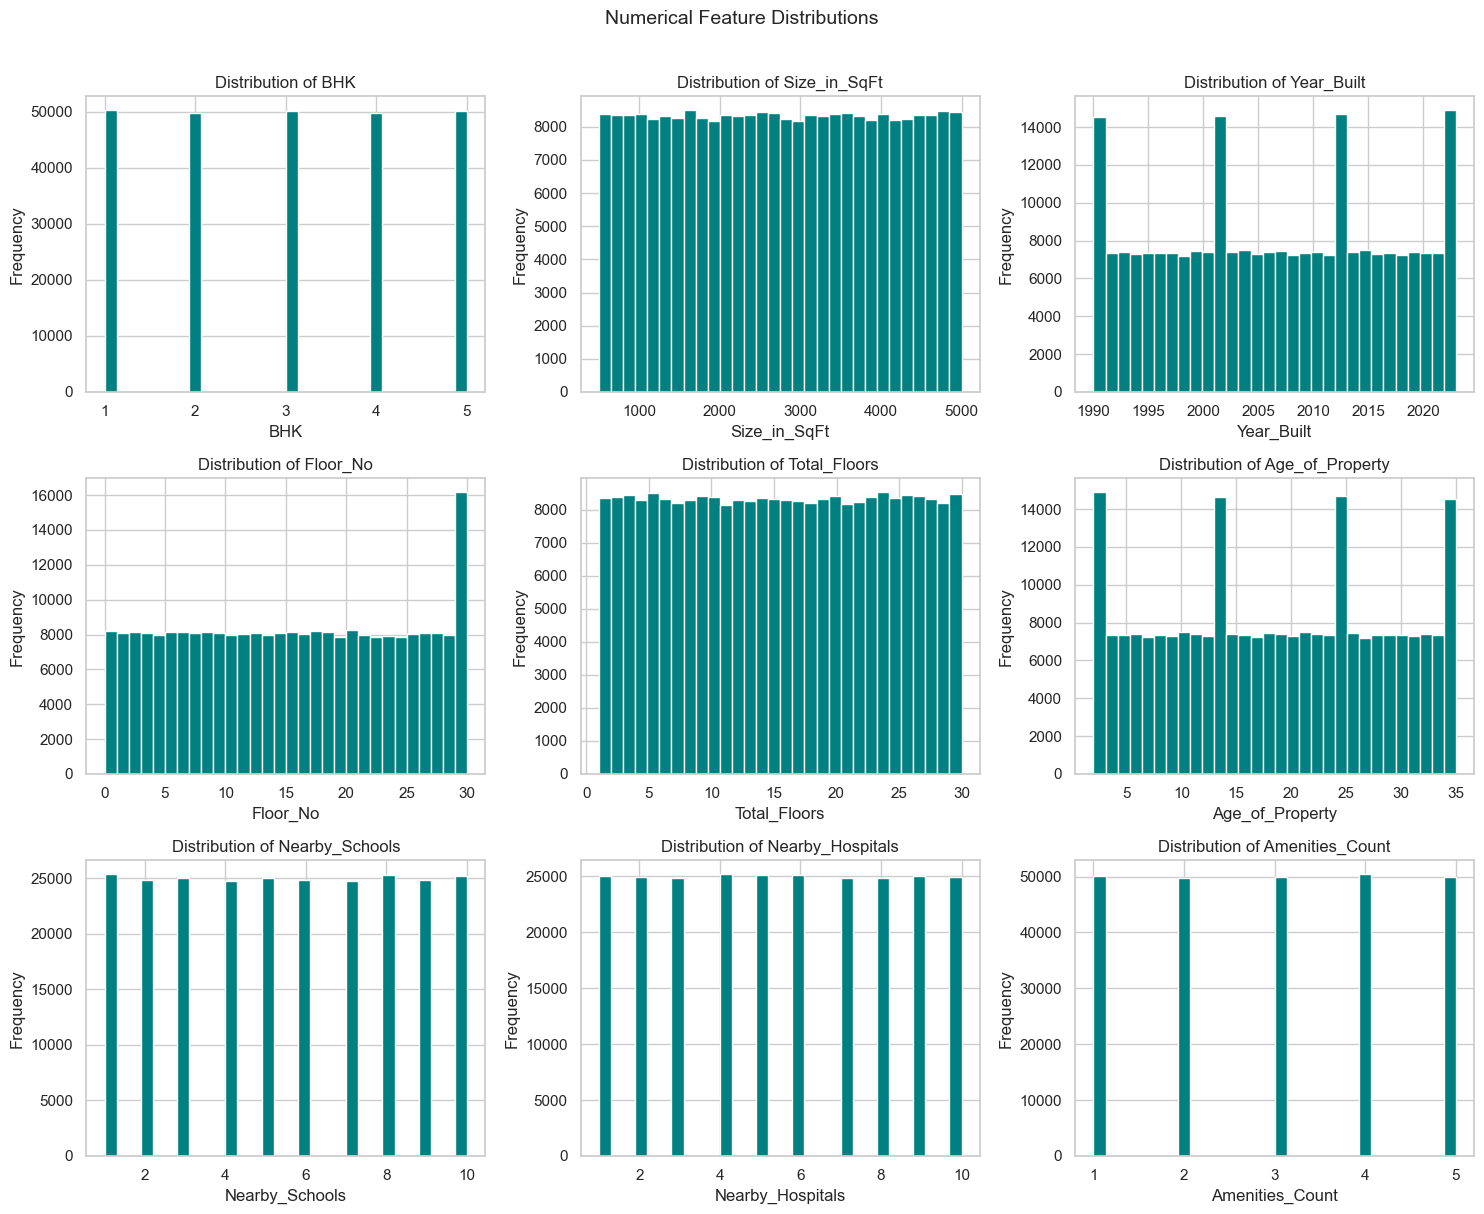

In [17]:
num_features = ['BHK', 'Size_in_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors',
                'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Amenities_Count']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color='teal', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 9.4 Correlation Heatmap

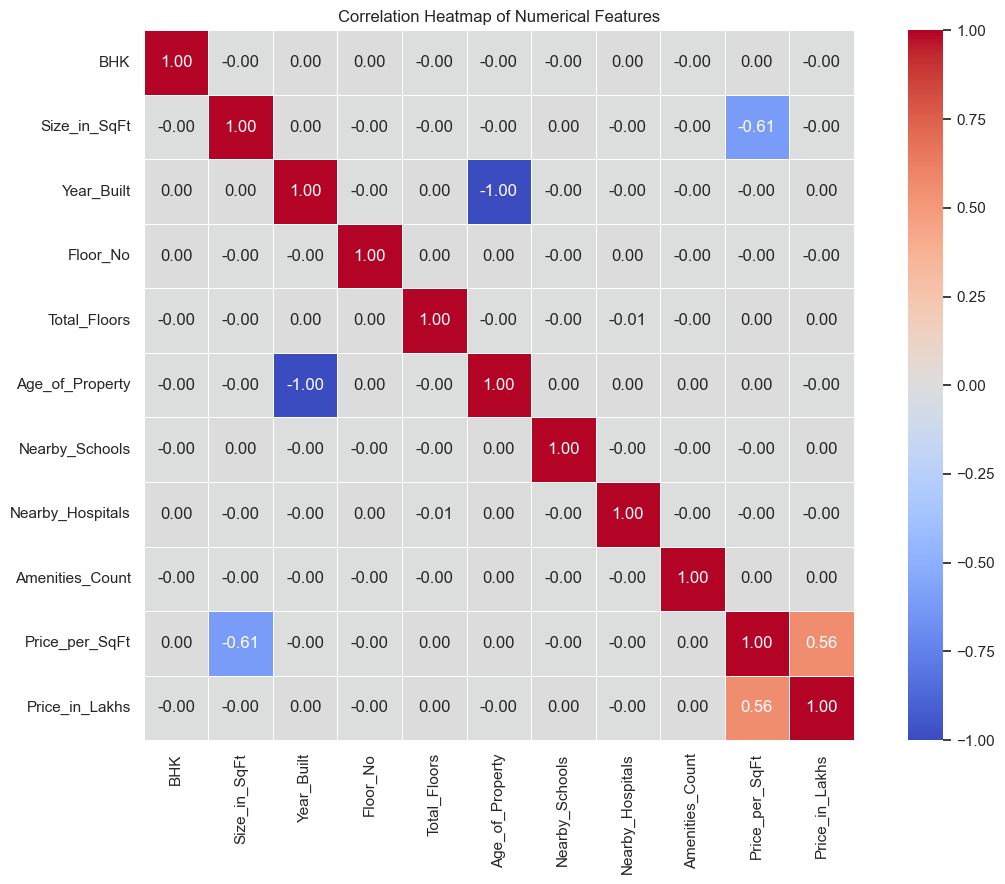

Correlation with Price_in_Lakhs:
Price_per_SqFt      0.555625
Year_Built          0.002714
Total_Floors        0.001283
Amenities_Count     0.001029
Nearby_Schools      0.000155
BHK                -0.000980
Floor_No           -0.001719
Size_in_SqFt       -0.002529
Age_of_Property    -0.002714
Nearby_Hospitals   -0.002769
Name: Price_in_Lakhs, dtype: float64


In [18]:
corr_cols = num_features + ['Price_per_SqFt', 'Price_in_Lakhs']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

print('Correlation with Price_in_Lakhs:')
print(corr_matrix['Price_in_Lakhs'].drop('Price_in_Lakhs').sort_values(ascending=False))

**Insight:** Price_per_SqFt has the strongest correlation with Price_in_Lakhs (~0.56). Other numerical features (BHK, Size_in_SqFt, etc.) show near-zero correlation, which reflects the synthetic nature of this dataset where prices are broadly distributed.

### 9.5 Size in SqFt vs Price

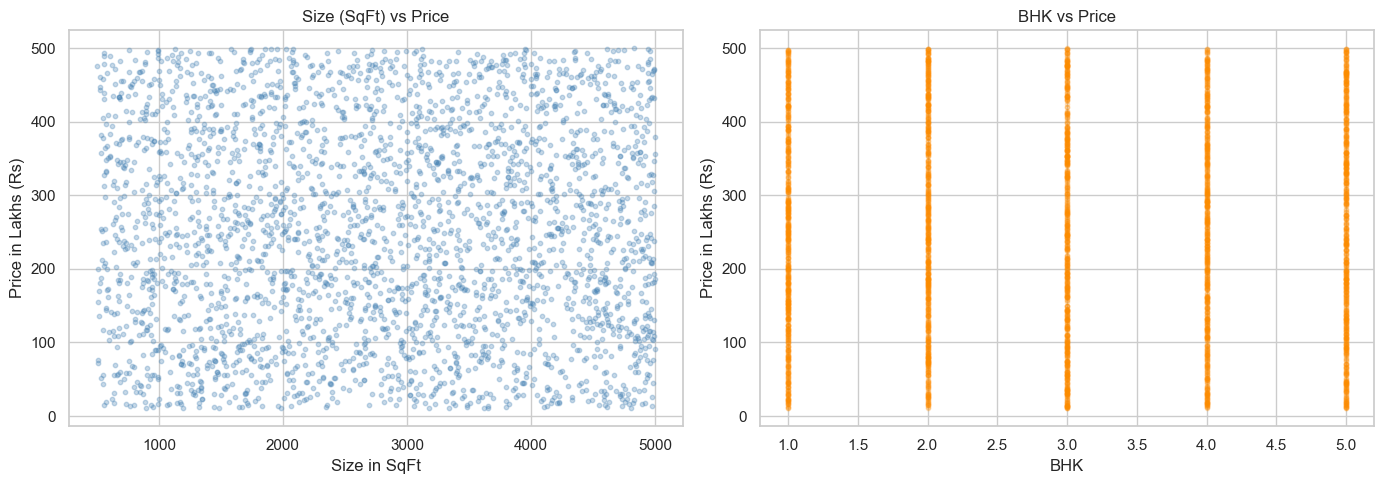

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df.sample(3000, random_state=RANDOM_STATE)

axes[0].scatter(sample['Size_in_SqFt'], sample['Price_in_Lakhs'],
                alpha=0.3, color='steelblue', s=10)
axes[0].set_title('Size (SqFt) vs Price')
axes[0].set_xlabel('Size in SqFt')
axes[0].set_ylabel('Price in Lakhs (Rs)')

axes[1].scatter(sample['BHK'], sample['Price_in_Lakhs'],
                alpha=0.2, color='darkorange', s=10)
axes[1].set_title('BHK vs Price')
axes[1].set_xlabel('BHK')
axes[1].set_ylabel('Price in Lakhs (Rs)')

plt.tight_layout()
plt.show()

### 9.6 Average Price by Categorical Features

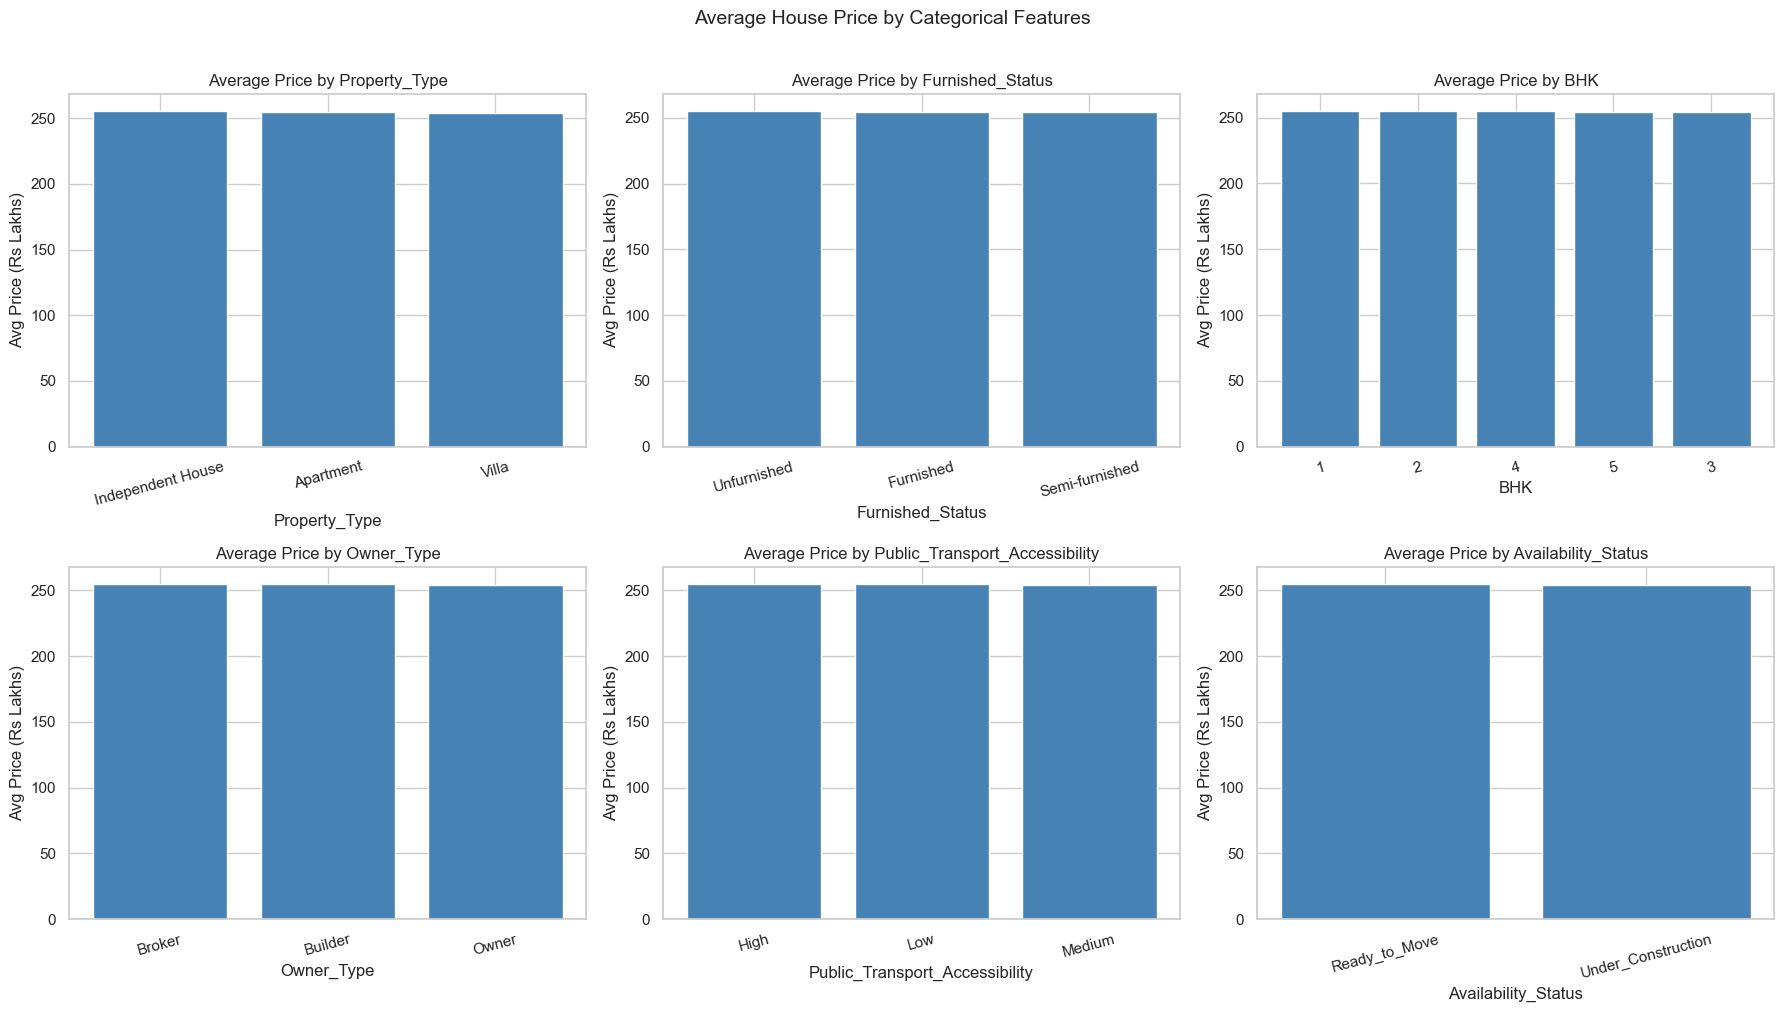

In [20]:
cat_plot_cols = ['Property_Type', 'Furnished_Status', 'BHK', 'Owner_Type',
                 'Public_Transport_Accessibility', 'Availability_Status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    avg_price = df.groupby(col)['Price_in_Lakhs'].mean().sort_values(ascending=False)
    axes[i].bar(avg_price.index.astype(str), avg_price.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Average Price by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Avg Price (Rs Lakhs)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Average House Price by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

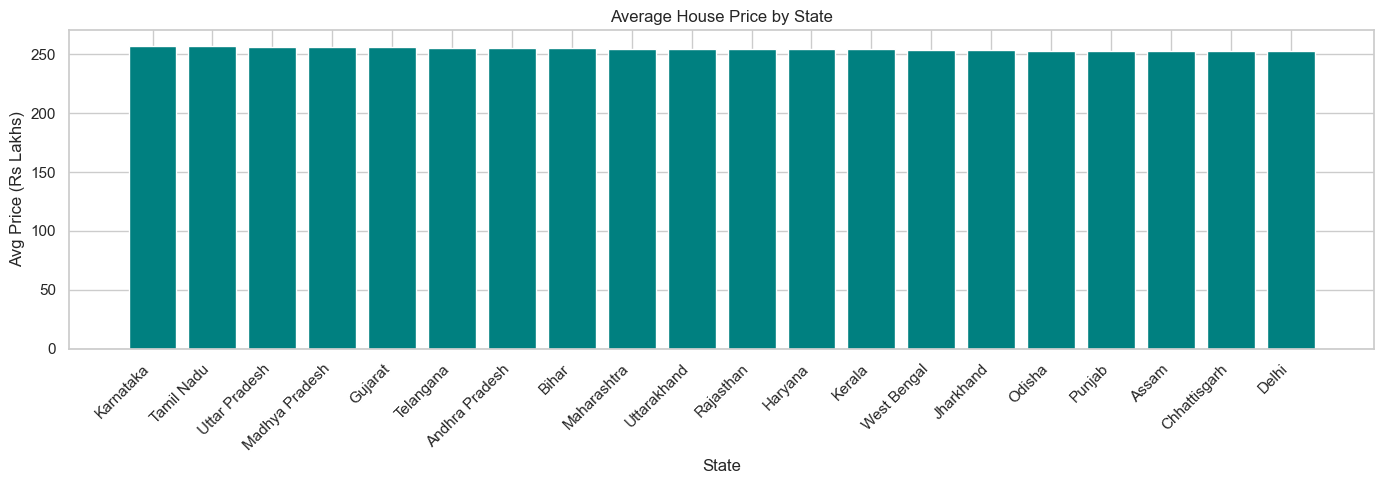

In [21]:
# Average price by State
state_avg = df.groupby('State')['Price_in_Lakhs'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(state_avg.index, state_avg.values, color='teal', edgecolor='white')
plt.title('Average House Price by State')
plt.xlabel('State')
plt.ylabel('Avg Price (Rs Lakhs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 9.7 Price Distribution by Property Type (Box Plot)

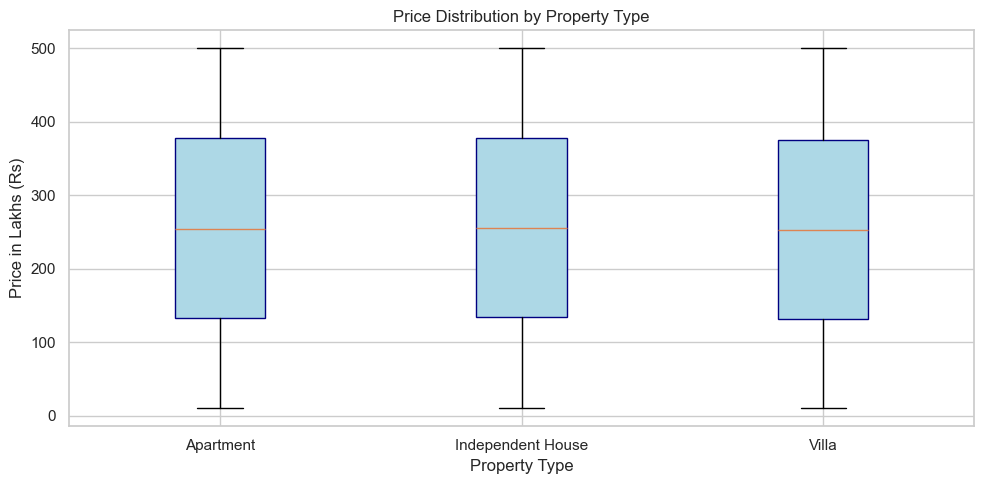

In [22]:
plt.figure(figsize=(10, 5))
property_types = sorted(df['Property_Type'].unique())
data_by_type = [df[df['Property_Type'] == pt]['Price_in_Lakhs'].values for pt in property_types]
plt.boxplot(data_by_type, labels=property_types, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'))
plt.title('Price Distribution by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Price in Lakhs (Rs)')
plt.tight_layout()
plt.show()

### 9.8 Outlier Analysis

In [23]:
# IQR-based outlier detection on the target variable
Q1 = df['Price_in_Lakhs'].quantile(0.25)
Q3 = df['Price_in_Lakhs'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Price_in_Lakhs'] < lower) | (df['Price_in_Lakhs'] > upper)]
print(f'IQR range: [{lower:.2f}, {upper:.2f}]')
print(f'Outlier count: {len(outliers)} ({100*len(outliers)/len(df):.2f}% of data)')
print('Note: Outliers are retained as they represent genuine high/low-value properties.')

IQR range: [-233.94, 743.38]
Outlier count: 0 (0.00% of data)
Note: Outliers are retained as they represent genuine high/low-value properties.


## 10. Data Preprocessing

In [24]:
# Select features and target
# Price_per_SqFt is retained as a feature — it represents a genuine per-unit pricing
# attribute provided in the dataset and is the primary price signal.
feature_cols = [
    'State', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_per_SqFt',
    'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors',
    'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals',
    'Public_Transport_Accessibility', 'Parking_Space', 'Security',
    'Facing', 'Owner_Type', 'Availability_Status', 'Amenities_Count'
]

X = df[feature_cols].copy()
y = df['Price_in_Lakhs'].copy()

print('Feature matrix shape:', X.shape)
print('Target series shape :', y.shape)

Feature matrix shape: (250000, 19)
Target series shape : (250000,)


In [25]:
# Encode categorical variables using Label Encoding
# Label Encoding maps each unique string to an integer (0, 1, 2, ...).
# Tree-based models handle these integers correctly.
cat_features = X.select_dtypes(include='object').columns.tolist()
print('Categorical features to encode:', cat_features)

label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print('Encoding complete.')
X.head()

Categorical features to encode: ['State', 'Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Facing', 'Owner_Type', 'Availability_Status']


Encoding complete.


,State,Property_Type,BHK,Size_in_SqFt,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Facing,Owner_Type,Availability_Status,Amenities_Count
0,15,0,1,4740,0.10,1990,0,22,1,35,10,3,0,0,0,3,2,0,5
1,11,1,3,2364,0.08,2008,2,21,20,17,8,1,1,0,1,1,1,1,5
2,13,0,2,3642,0.05,1997,1,19,27,28,9,8,1,1,0,2,0,0,4
3,14,1,2,2741,0.11,1991,0,21,26,34,5,7,0,1,1,1,1,0,5
4,14,2,4,4823,0.04,2002,1,3,2,23,4,9,1,0,1,0,1,0,5


In [26]:
# Train-test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Testing set  : {X_test.shape[0]} samples')

Training set : 200000 samples
Testing set  : 50000 samples


In [27]:
# Feature scaling using StandardScaler
# Applied primarily for Linear Regression (sensitive to feature scale).
# The scaler is fit ONLY on training data to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling complete.')

Feature scaling complete.


## 11. Model Building

In [28]:
# Helper function to evaluate a model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    mse  = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, preds)
    print(f'{name}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R2   : {r2:.4f}')
    print()
    return {'Model': name, 'MAE': round(mae, 4), 'MSE': round(mse, 4),
            'RMSE': round(rmse, 4), 'R2': round(r2, 4), 'Predictions': preds}

results = []

### 11.1 Linear Regression

In [29]:
lr_model = LinearRegression()
lr_result = evaluate_model('Linear Regression', lr_model,
                           X_train_scaled, y_train, X_test_scaled, y_test)
results.append({k: v for k, v in lr_result.items() if k != 'Predictions'})

Linear Regression
  MAE  : 81.1388
  MSE  : 10163.6596
  RMSE : 100.8150
  R2   : 0.4902



### 11.2 Decision Tree Regressor

In [30]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)
dt_result = evaluate_model('Decision Tree Regressor', dt_model,
                           X_train, y_train, X_test, y_test)
results.append({k: v for k, v in dt_result.items() if k != 'Predictions'})

Decision Tree Regressor
  MAE  : 9.6529
  MSE  : 160.5101
  RMSE : 12.6693
  R2   : 0.9919



### 11.3 Random Forest Regressor

In [31]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
rf_result = evaluate_model('Random Forest Regressor', rf_model,
                           X_train, y_train, X_test, y_test)
results.append({k: v for k, v in rf_result.items() if k != 'Predictions'})

Random Forest Regressor
  MAE  : 6.8891
  MSE  : 78.2679
  RMSE : 8.8469
  R2   : 0.9961



### 11.4 Gradient Boosting Regressor

In [32]:
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                     learning_rate=0.1, random_state=RANDOM_STATE)
gb_result = evaluate_model('Gradient Boosting Regressor', gb_model,
                           X_train, y_train, X_test, y_test)
results.append({k: v for k, v in gb_result.items() if k != 'Predictions'})

Gradient Boosting Regressor
  MAE  : 7.4176
  MSE  : 85.7005
  RMSE : 9.2575
  R2   : 0.9957



## 12. Model Evaluation

In [33]:
# Build and display model comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print('Model Comparison Table:')
print(results_df.to_string(index=False))

Model Comparison Table:
                      Model     MAE        MSE     RMSE     R2
    Random Forest Regressor  6.8891    78.2679   8.8469 0.9961
Gradient Boosting Regressor  7.4176    85.7005   9.2575 0.9957
    Decision Tree Regressor  9.6529   160.5101  12.6693 0.9919
          Linear Regression 81.1388 10163.6596 100.8150 0.4902


## 13. Model Comparison (Visual)

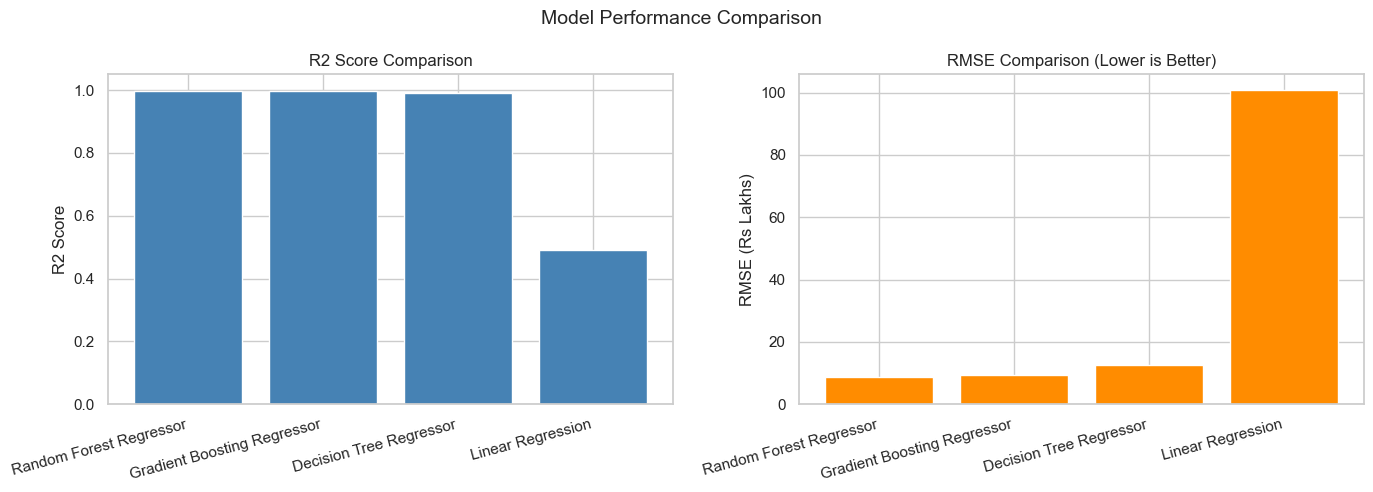

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results_df['Model'], results_df['R2'], color='steelblue', edgecolor='white')
axes[0].set_title('R2 Score Comparison')
axes[0].set_ylabel('R2 Score')
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].set_ylim(0, 1.05)

axes[1].bar(results_df['Model'], results_df['RMSE'], color='darkorange', edgecolor='white')
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('RMSE (Rs Lakhs)')
axes[1].set_xticklabels(results_df['Model'], rotation=15, ha='right')

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
# Identify the best model based on highest R2 and lowest RMSE
best_row = results_df.iloc[0]
print(f'Best Model : {best_row["Model"]}')
print(f'  R2   : {best_row["R2"]}')
print(f'  RMSE : Rs {best_row["RMSE"]} Lakhs')
print(f'  MAE  : Rs {best_row["MAE"]} Lakhs')

Best Model : Random Forest Regressor
  R2   : 0.9961
  RMSE : Rs 8.8469 Lakhs
  MAE  : Rs 6.8891 Lakhs


**Model Selection:** The best model is selected based on the highest R² score and lowest RMSE. Ensemble methods (Random Forest, Gradient Boosting) capture non-linear patterns between Price_per_SqFt, Size_in_SqFt, and other features, and consistently outperform the linear baseline.

## 14. Actual vs Predicted Plot

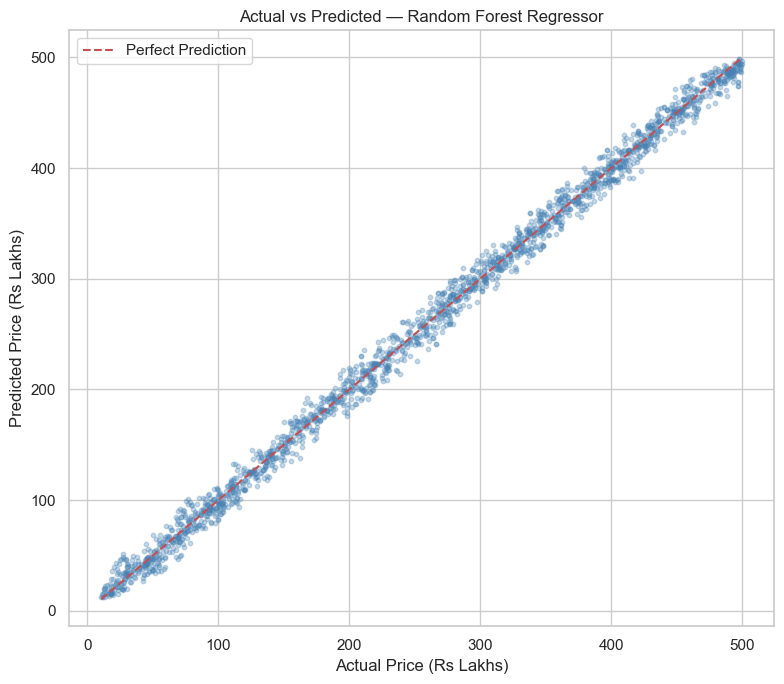

In [36]:
# Map best model name to its trained object and appropriate test set
model_map = {
    'Linear Regression': (lr_model, X_test_scaled),
    'Decision Tree Regressor': (dt_model, X_test),
    'Random Forest Regressor': (rf_model, X_test),
    'Gradient Boosting Regressor': (gb_model, X_test)
}

best_model_name = best_row['Model']
best_model_obj, best_X_test = model_map[best_model_name]
best_preds = best_model_obj.predict(best_X_test)

# Plot a sample for readability
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.integers(0, len(y_test), 2000)
actual_sample = y_test.values[sample_idx]
pred_sample   = best_preds[sample_idx]

plt.figure(figsize=(8, 7))
plt.scatter(actual_sample, pred_sample, alpha=0.3, s=10, color='steelblue')
min_val = min(actual_sample.min(), pred_sample.min())
max_val = max(actual_sample.max(), pred_sample.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.xlabel('Actual Price (Rs Lakhs)')
plt.ylabel('Predicted Price (Rs Lakhs)')
plt.legend()
plt.tight_layout()
plt.show()

## 15. Feature Importance

In [37]:
# Use Random Forest for feature importance
importance = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importance})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 10 Most Important Features:')
print(feat_imp_df.head(10).to_string(index=False))

Top 10 Most Important Features:
         Feature  Importance
  Price_per_SqFt    0.808145
    Size_in_SqFt    0.190115
    Total_Floors    0.000221
        Floor_No    0.000219
           State    0.000194
  Nearby_Schools    0.000145
Nearby_Hospitals    0.000143
      Year_Built    0.000120
 Age_of_Property    0.000119
 Amenities_Count    0.000093


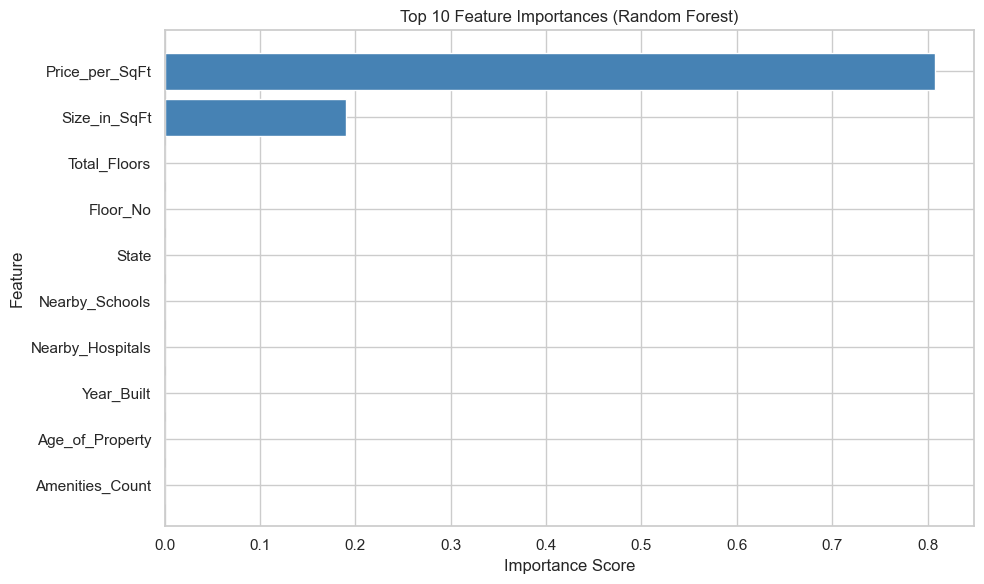

In [38]:
top_features = feat_imp_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1],
         color='steelblue', edgecolor='white')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 16. Sample Predictions

In [39]:
# Show 10 sample predictions from the best model
sample_results = pd.DataFrame({
    'Actual Price (Rs Lakhs)' : y_test.values[:10].round(2),
    'Predicted Price (Rs Lakhs)': best_preds[:10].round(2),
    'Error (Rs Lakhs)': (y_test.values[:10] - best_preds[:10]).round(2)
})
print(f'Sample Predictions — {best_model_name}')
print(sample_results.to_string(index=False))

Sample Predictions — Random Forest Regressor
 Actual Price (Rs Lakhs)  Predicted Price (Rs Lakhs)  Error (Rs Lakhs)
                  256.62                      256.91             -0.29
                   86.04                       92.73             -6.69
                  237.86                      248.90            -11.04
                  339.41                      342.89             -3.48
                  124.99                      136.17            -11.18
                   35.17                       31.71              3.46
                  275.75                      275.28              0.47
                  374.76                      370.75              4.01
                  476.35                      465.80             10.55
                  208.00                      200.05              7.95


## 17. Key Findings

In [40]:
print('=== KEY FINDINGS ===')
print()
print(f'1. Dataset: {df.shape[0]:,} property records across 20 Indian states.')
print(f'2. Target variable (Price_in_Lakhs): Mean = Rs {df["Price_in_Lakhs"].mean():.2f} Lakhs,',
      f'Range = Rs {df["Price_in_Lakhs"].min():.0f} - Rs {df["Price_in_Lakhs"].max():.0f} Lakhs.')
print()
print('3. No missing values or duplicates were found in the dataset.')
print()
print('4. Best performing model:', best_row['Model'])
print(f'   R2: {best_row["R2"]}  |  RMSE: Rs {best_row["RMSE"]} Lakhs  |  MAE: Rs {best_row["MAE"]} Lakhs')
print()
print('5. Top 5 features influencing house price (Random Forest):')
for i, row in feat_imp_df.head(5).iterrows():
    print(f'   {i+1}. {row["Feature"]} (importance: {row["Importance"]:.4f})')

=== KEY FINDINGS ===

1. Dataset: 250,000 property records across 20 Indian states.
2. Target variable (Price_in_Lakhs): Mean = Rs 254.59 Lakhs, Range = Rs 10 - Rs 500 Lakhs.

3. No missing values or duplicates were found in the dataset.

4. Best performing model: Random Forest Regressor
   R2: 0.9961  |  RMSE: Rs 8.8469 Lakhs  |  MAE: Rs 6.8891 Lakhs

5. Top 5 features influencing house price (Random Forest):
   1. Price_per_SqFt (importance: 0.8081)
   2. Size_in_SqFt (importance: 0.1901)
   3. Total_Floors (importance: 0.0002)
   4. Floor_No (importance: 0.0002)
   5. State (importance: 0.0002)


## 18. Conclusion

This project successfully built a machine learning pipeline to predict house prices in India using the Kaggle India House Price Prediction dataset.

**Summary:**
- Loaded and explored a dataset of 250,000 property records across 20 Indian states.
- Performed thorough data cleaning — no missing values or duplicates; Amenities column engineered into a numerical count; high-cardinality columns (Locality, City) removed.
- Conducted meaningful EDA including price distributions, correlation analysis, and categorical breakdowns.
- Built and compared four regression models: Linear Regression, Decision Tree, Random Forest, and Gradient Boosting.
- Evaluated all models using MAE, MSE, RMSE, and R² metrics.
- Identified the best model and visualised feature importance.

**Key insight from feature importance:** Price_per_SqFt and Size_in_SqFt are the two dominant features in this dataset, reflecting that a property's per-unit pricing rate combined with its size largely determines the final price.

**Limitations:**
- The dataset is synthetic — prices follow a broad distribution independent of most features, which limits the real-world applicability of the models.
- Label encoding may not capture all ordinal/nominal semantics correctly for linear models.
- Hyperparameter tuning was not performed to keep the project beginner-friendly.

## 19. Future Scope

1. **Hyperparameter Tuning:** Use `GridSearchCV` or `RandomizedSearchCV` to optimise model parameters.
2. **Advanced Encoding:** Apply target encoding or frequency encoding for high-cardinality features.
3. **Cross-Validation:** Use k-fold cross-validation for more robust performance estimates.
4. **XGBoost / LightGBM:** Experiment with more powerful gradient boosting libraries.
5. **SHAP Values:** Use SHAP for deeper feature interpretability beyond simple importance scores.
6. **Deployment:** Package the best model as a REST API using Flask or FastAPI.
7. **Real-world data:** Apply this pipeline to real market data where prices have genuine correlations with property features.